In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('ai_student_impact_dataset (1).csv')

In [4]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

In [6]:
BLUE   = "#1B7ABF"
ORANGE = "#E07B39"
GRAY   = "#AAAAAA"
RED    = "#D94F3D"
GREEN  = "#2E9B6F"
TEXT   = "#444444"
SUB    = "#555555"
FOOT   = "#888888"

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

In [12]:
BLUE    = "#1B7ABF"
LBLUE   = "#A8D1F0"
RED     = "#D94F3D"
LRED    = "#F5B8B2"
GRAY    = "#CCCCCC"
DGRAY   = "#888888"
TEXT    = "#2A2A2A"
SUB     = "#666666"
FOOT    = "#999999"
BG      = "#FAFAFA"
TEXT_COLOR = "black"
SUB = "#555555"

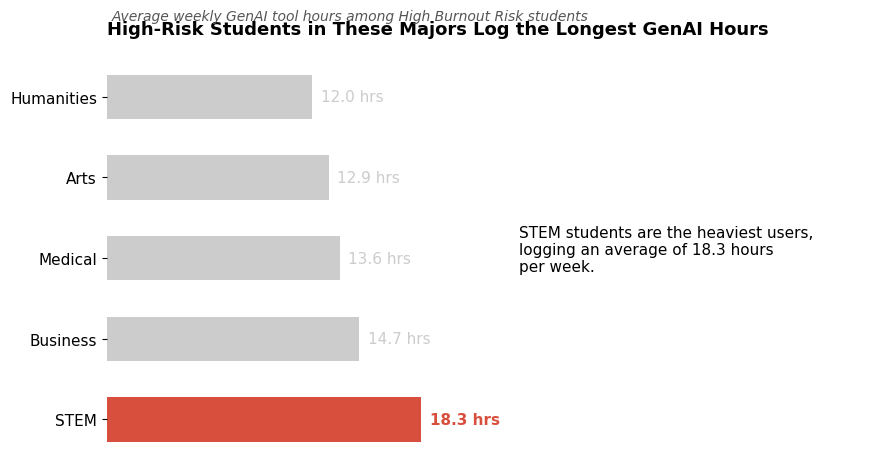

In [13]:
# Isolate high-risk individuals and find their mean weekly GenAI hours
high_risk_df = df[df["Burnout_Risk_Level"] == "High"]

major_burnout = (
    df.groupby("Major_Category")["Burnout_Risk_Level"]
    .value_counts(normalize=True)
    .unstack()["High"]
    * 100
).sort_values(ascending=False)

major_hours = (
    high_risk_df.groupby("Major_Category")["Weekly_GenAI_Hours"]
    .mean()
    .loc[major_burnout.index]
)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bar_colors_2 = [RED if idx == "STEM" else GRAY for idx in major_hours.index]
bars2 = ax.barh(
    major_hours.index, major_hours.values, color=bar_colors_2, height=0.55
)

# Value labels
for bar in bars2:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f} hrs",
        va="center",
        ha="left",
        fontsize=11,
        color=RED if width > 17 else GRAY,
        fontweight="bold" if width > 17 else "normal",
    )

# --- STORYTELLING TEXT INSIDE THE PLOT BLANK SPACE ---
story_text_2 = (
    "STEM students are the heaviest users,\n"
    "logging an average of 18.3 hours\n"
    "per week.\n"
)
ax.text(
    24,
    2.0,
    story_text_2,
    fontsize=11,
    color=TEXT_COLOR,
    va="center",
    ha="left",
)

ax.set_title(
    "High-Risk Students in These Majors Log the Longest GenAI Hours",
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=16,
    color=TEXT_COLOR,
)
fig.text(
    0.13,
    0.93,
    "Average weekly GenAI tool hours among High Burnout Risk students",
    fontsize=10,
    color=SUB,
    style="italic",
)

ax.set_xlim(0, 45)  # Extended to leave room for narrative text
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(axis="y", labelsize=11, colors=TEXT_COLOR)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig("chart2_hours.png", dpi=300)
plt.show()

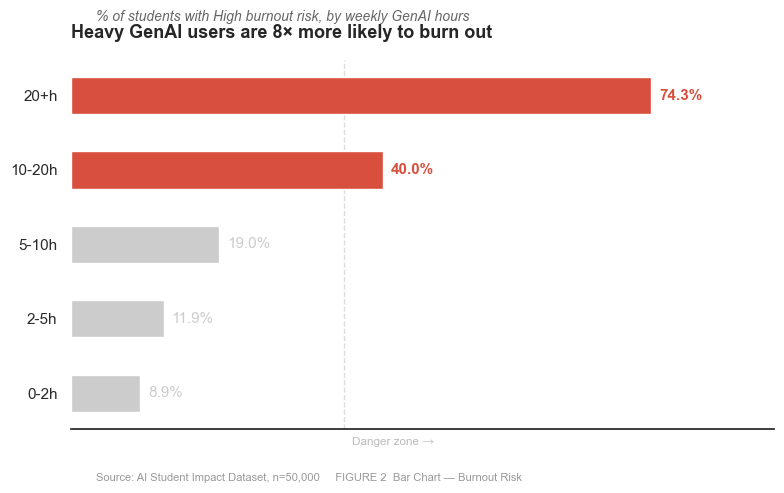

In [32]:
sns.set_theme(style="white")
buckets = ["0-2h", "2-5h", "5-10h", "10-20h", "20+h"]
pct     = [8.9, 11.9, 19.0, 40.0, 74.3]
 
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
 
bar_colors = [GRAY if p < 30 else RED for p in pct]
bars = ax.barh(buckets, pct, color=bar_colors, height=0.5, zorder=2)
 
for bar, p in zip(bars, pct):
    ax.text(p + 1, bar.get_y() + bar.get_height()/2,
            f"{p}%", va="center", fontsize=11,
            color=RED if p >= 35 else GRAY,
            fontweight="bold" if p >= 35 else "normal")
 
ax.axvline(35, color="#DDDDDD", linewidth=1, linestyle="--", zorder=1)
ax.text(36, -0.7, "Danger zone →", fontsize=8.5, color="#BBBBBB")
 
ax.set_title("Heavy GenAI users are 8× more likely to burn out",
             fontsize=13, fontweight="bold", loc="left", pad=16)
fig.text(0.13, 0.93, "% of students with High burnout risk, by weekly GenAI hours",
         fontsize=10, color=SUB, style="italic")
fig.text(0.13, 0.01, "Source: AI Student Impact Dataset, n=50,000     FIGURE 2  Bar Chart — Burnout Risk",
         fontsize=8, color=FOOT)
 
ax.set_xlabel("% with High burnout risk", fontsize=10, color=SUB)
ax.set_xlim(0, 90)
ax.spines[["top","right","left"]].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(axis="y", labelsize=11, colors=TEXT)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()
 